# Simulation providing evidence that (n-1) gives us unbiased estimate

[Simulation providing evidence that (n-1) gives us unbiased estimate | Khan Academy | YouTube](https://www.youtube.com/watch?v=0QS4VHPV4JA)

# Why We Divide by *n − 1*: An Intuitive Simulation Summary

This document summarizes a Khan Academy simulation (created by user **TETF**) that provides intuition for why sample variance is calculated using **n − 1** rather than **n**.

---

## 1. Building a Population

The simulation allows the user to create a **population distribution** by clicking to add data points. As points are added, the following true population parameters are computed:

- **Population mean**
- **Population variance**
- **Population standard deviation** (the square root of variance)

These parameters serve as the reference for evaluating different sample-based variance formulas.

---

## 2. Taking Samples and Testing Variance Formulas

Once a population is created, the simulation repeatedly:

1. Draws a **random sample** of size *n*.
2. Computes a variance-like statistic of the form:

$$
  \frac{\sum (x_i - \bar{x})^2}{n + a}
$$

   where **a** is a value that may be negative, zero, or positive.
3. Repeats this many times and averages the results.

By varying **a**, the simulation tests which denominator leads to the most accurate estimate of the **true population variance**.

---

## 3. What the Simulation Shows

Across many repeated samples:

- When **a > -1** (e.g., dividing by *n*, where *a = 0*), the resulting variance estimate is **too small** — it **underestimates** the true variance.
- When **a < -1**, the estimate is **too large** — it **overestimates** the true variance.
- When **a = -1**, meaning the denominator becomes **n − 1**, the estimate is **unbiased** — on average, it matches the true population variance.

This result holds consistently across different sample sizes. With large numbers of repeated samples, the simulation clearly shows that **n − 1** yields the most accurate average estimate.

---

## 4. Why This Happens (Intuition)

Using the sample mean in the calculation makes the sample deviations slightly smaller than the true deviations from the population mean. Because of this, dividing by *n* is not enough — it systematically underestimates the true spread.

Dividing by **n − 1**, known as **Bessel’s correction**, compensates for this bias.

---

## 5. Conclusion

The Khan Academy simulation visually and empirically demonstrates that:

- Dividing by **n − 1** produces an **unbiased estimator** of population variance.
- Dividing by **n** consistently underestimates the true variance.
- Values smaller than **n − 1** overestimate variance.

This gives an intuitive understanding of why statistics textbooks use **n − 1** when computing sample variance.


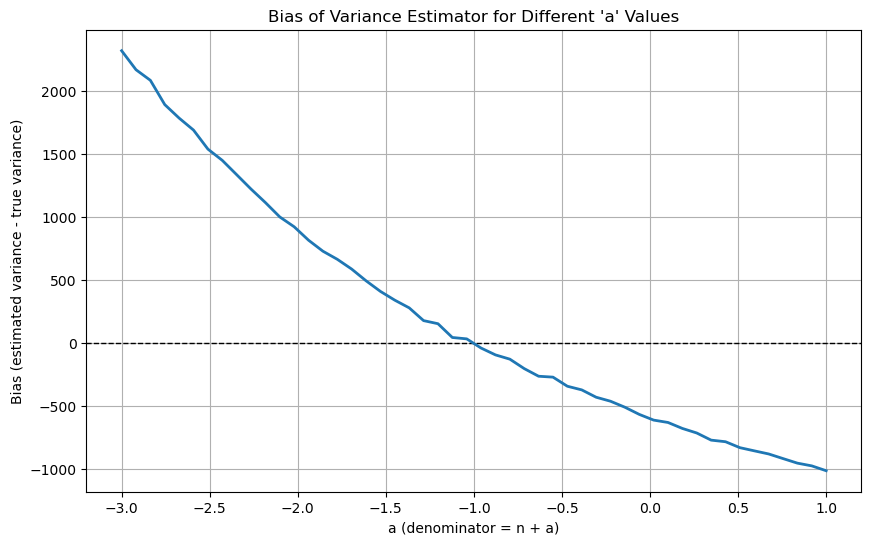

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def population(mean=200, std=60, size=5000):
    """Create a synthetic population."""
    return np.random.normal(mean, std, size)

def sample_variance(x, a):
    """
    Compute variance estimate with denominator n + a.
    a = -1 corresponds to dividing by n - 1.
    """
    n = len(x)
    mean_x = np.mean(x)
    return np.sum((x - mean_x)**2) / (n + a)

def run_simulation(pop, sample_size=5, a_values=None, num_samples=20000):
    """Run repeated sampling and test bias for different a values."""
    if a_values is None:
        a_values = np.linspace(-3, 1, 50)

    true_var = np.var(pop)  # population variance
    bias_results = []

    for a in a_values:
        estimates = []
        for _ in range(num_samples):
            s = np.random.choice(pop, size=sample_size, replace=True)
            estimates.append(sample_variance(s, a))
        mean_estimate = np.mean(estimates)
        bias = mean_estimate - true_var
        bias_results.append(bias)

    return a_values, bias_results, true_var

# Run simulation
pop = population()
a_vals, biases, true_var = run_simulation(pop, sample_size=6)

# Plot results
plt.figure(figsize=(10, 6))
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.plot(a_vals, biases, linewidth=2)

plt.title("Bias of Variance Estimator for Different 'a' Values")
plt.xlabel("a (denominator = n + a)")
plt.ylabel("Bias (estimated variance - true variance)")
plt.grid(True)
plt.show()


## 🧠 What the program does:

* Creates a population with known variance
* Repeatedly samples from it
* Computes sample variance using different denominators **(n + a)**
* Plots bias vs. **a**
* Shows that **a = -1 (divide by n−1)** gives zero bias


# [Context](https://github.com/progressivepull/Statistics-Deep-Dives/blob/main/khan_academy/Content.md)